# Regression like transfer function- Linear Model

In [1]:
import numpy as np
import xarray as xr
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.waves.estela import ESTELA
from utils.data import load_atmospheric_predictor
from utils.funcs_linear import fit_plot_linear_model, plot_pcs, plot_waves

## Predictor- Load large scale atmospheric variables
### mean sea level pressure, spatial gradient of mean sea level pressure

In [2]:
# Define the variables and region
variables = ["msl", "msl_gradient"]
region = (200, -10, 360, 80)
estela = False

# Load the ERA5 predictors
era5 = load_atmospheric_predictor(variables=variables, region=region, estela=estela)
era5

<xarray.Dataset> Size: 124MB
Dimensions:       (time: 16802, latitude: 23, longitude: 40)
Coordinates:
  * latitude      (latitude) float32 92B 80.0 76.0 72.0 68.0 ... 0.0 -4.0 -8.0
  * longitude     (longitude) float32 160B 200.0 204.0 208.0 ... 352.0 356.0
  * time          (time) datetime64[s] 134kB 1979-01-01 ... 2024-12-31
Data variables:
    msl           (time, latitude, longitude) float32 62MB 1.022e+05 ... 1.01...
    msl_gradient  (time, latitude, longitude) float32 62MB 1.765e+05 ... 719.4
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [41]:
# # If cell above takes too long, run:
# !wget https://geoocean.sci.unican.es/data/era5_predictor_aveiro.nc -P inputs/

# # Then run:
# era5 = xr.open_dataset("inputs/era5_predictor_aveiro.nc")
# era5

## Predictor- define indices/covariates/input layers
### PCA- Principal Component Analysis + reduce dimensionality

In [20]:
pca = PCA(n_components=0.9)

_pcs = pca.fit_transform(
    data=era5,
    vars_to_stack=["msl", "msl_gradient"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
    value_to_replace_nans={"msl": 101325.0, "msl_gradient": 0.0},
)
_pcs

2025-08-26 06:55:20,074 - PCA - WARNING - Using 920 out of 920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-26 06:55:20,608 - PCA - WARNING - Using 920 out of 920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 25MB
Dimensions:      (time: 16802, n_component: 365)
Coordinates:
  * time         (time) datetime64[s] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * n_component  (n_component) int64 3kB 0 1 2 3 4 5 ... 359 360 361 362 363 364
Data variables:
    PCs          (time, n_component) float32 25MB -24.83 12.71 ... -1.226 0.1022
    stds         (n_component) float32 1kB 13.7 11.55 9.672 ... 0.8077 0.8061

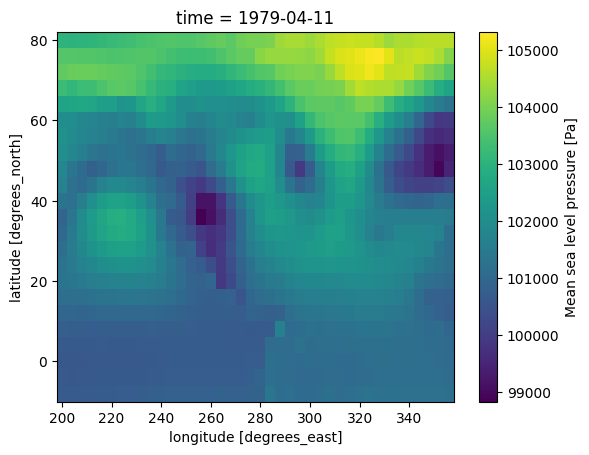

In [21]:
era5.msl.isel(time=100).plot()

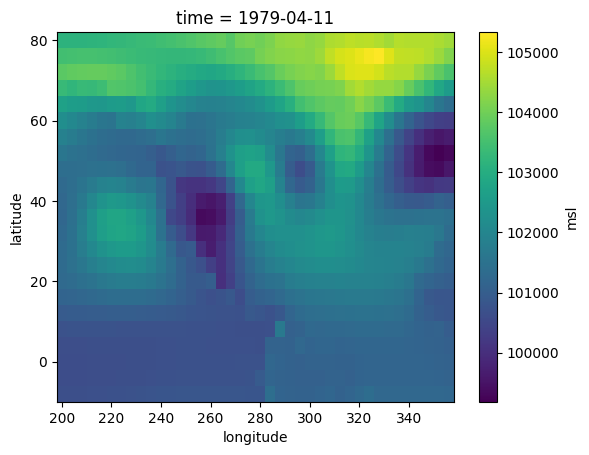

In [22]:
pca.inverse_transform(_pcs.isel(time=[100])).msl.plot()

### PCA- spatial modes EOF

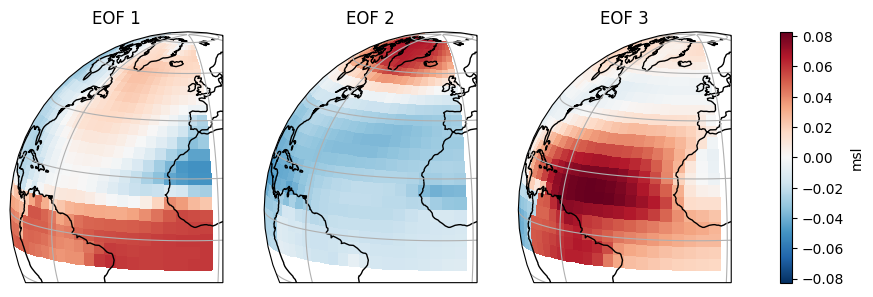

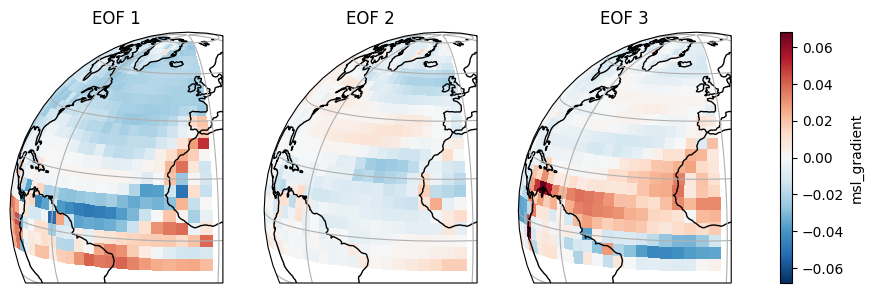

In [23]:
pca.plot_eofs(num_eofs=3, vars_to_plot=["msl", "msl_gradient"], map_center=(-10, 10))

### PCA- temporal indices PCs

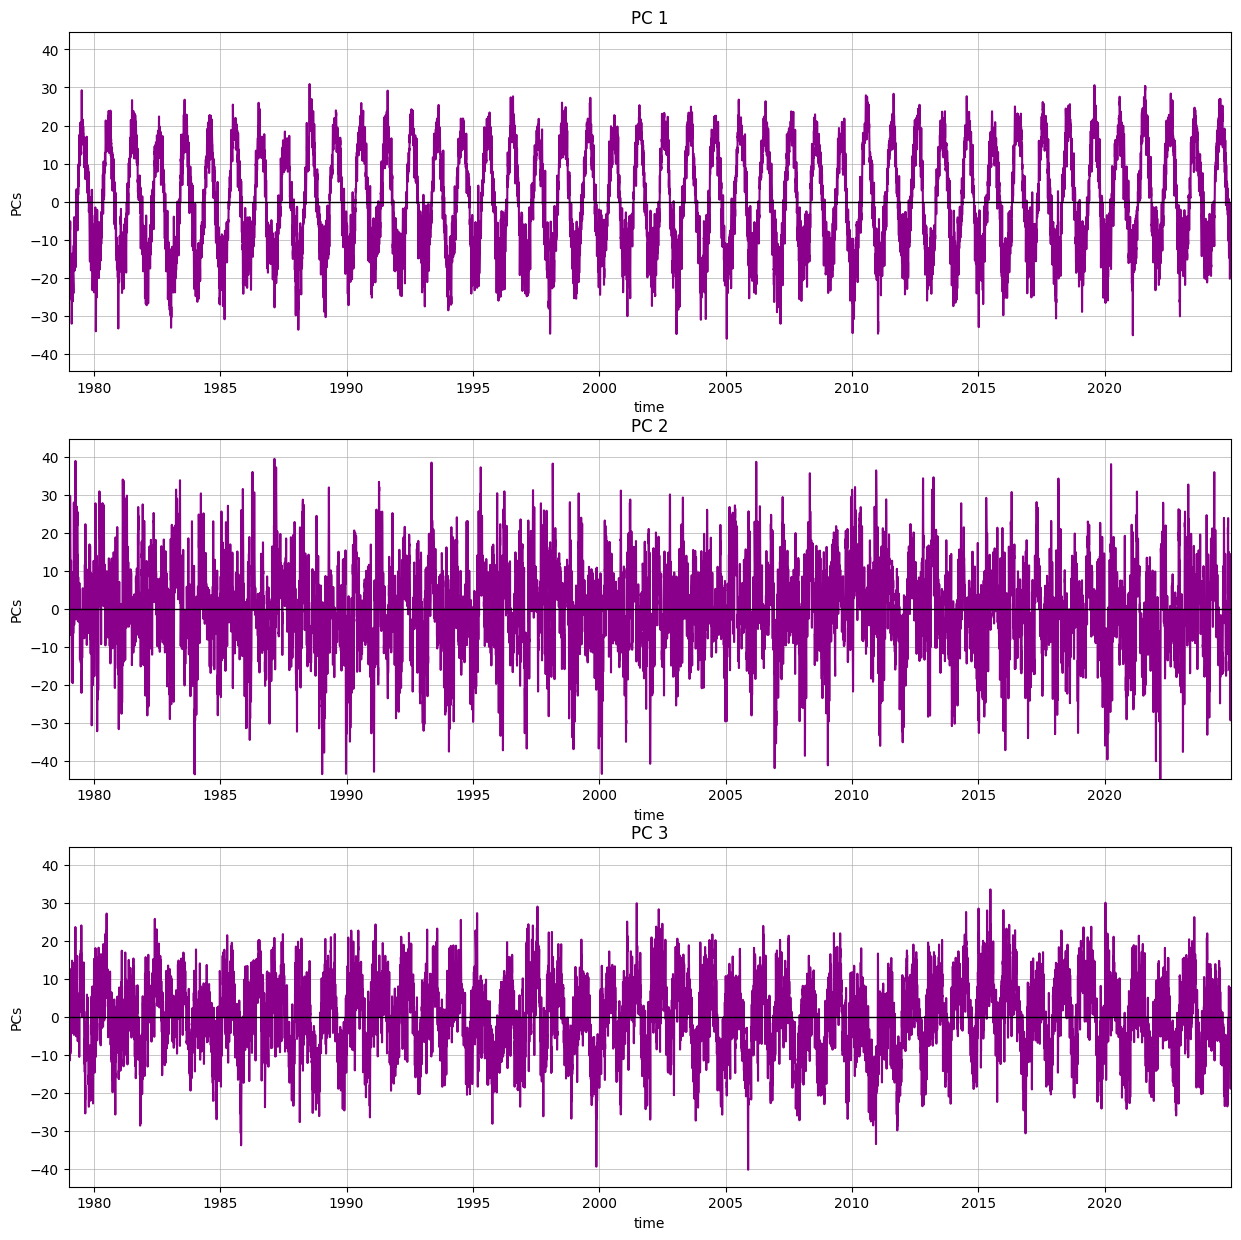

In [24]:
n_pcs = 3
plot_pcs(pca, n_pcs)

## Predictand- Load regional/local wave data
### significant wave height, peak period

In [25]:
waves = xr.open_dataset("inputs/waves_EF_daily.nc")[["swh", "EF"]]

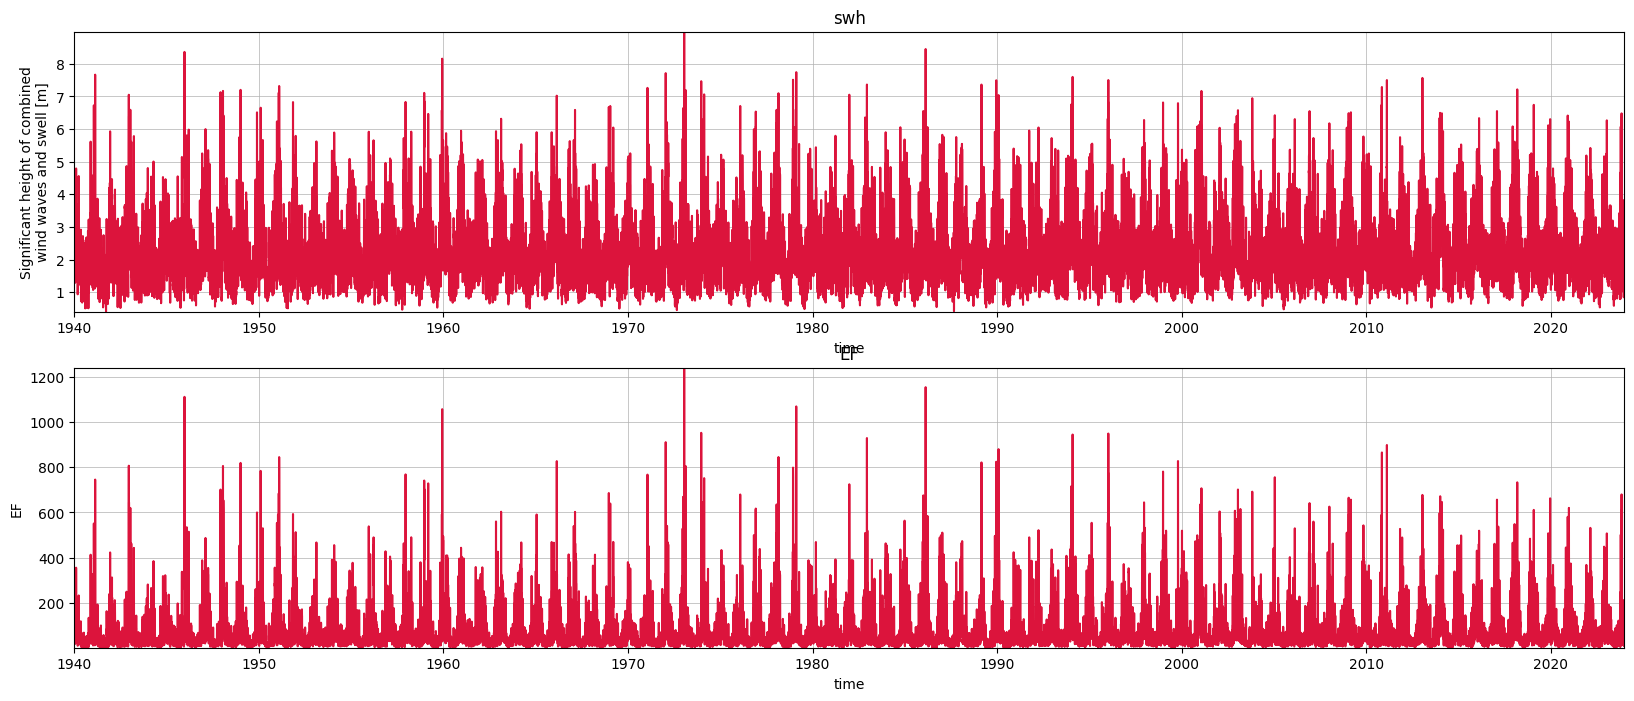

In [26]:
plot_waves(waves)

## Predictand to Predictor - Model
### Multiple Linear Regression
X - temporal indices PCs- Predictor: regressors, exogenous variables, explanatory variables, covariates, input variables, predictor variables, or independent variables

Y - wave parameter- Predictand: regressand, endogenous variable, response variable, target variable, measured variable, criterion variable, or dependent variable

In [27]:
pca.pcs

<xarray.Dataset> Size: 25MB
Dimensions:      (time: 16802, n_component: 365)
Coordinates:
  * time         (time) datetime64[s] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * n_component  (n_component) int64 3kB 0 1 2 3 4 5 ... 359 360 361 362 363 364
Data variables:
    PCs          (time, n_component) float32 25MB -24.83 12.71 ... -1.226 0.1022
    stds         (n_component) float32 1kB 13.7 11.55 9.672 ... 0.8077 0.8061

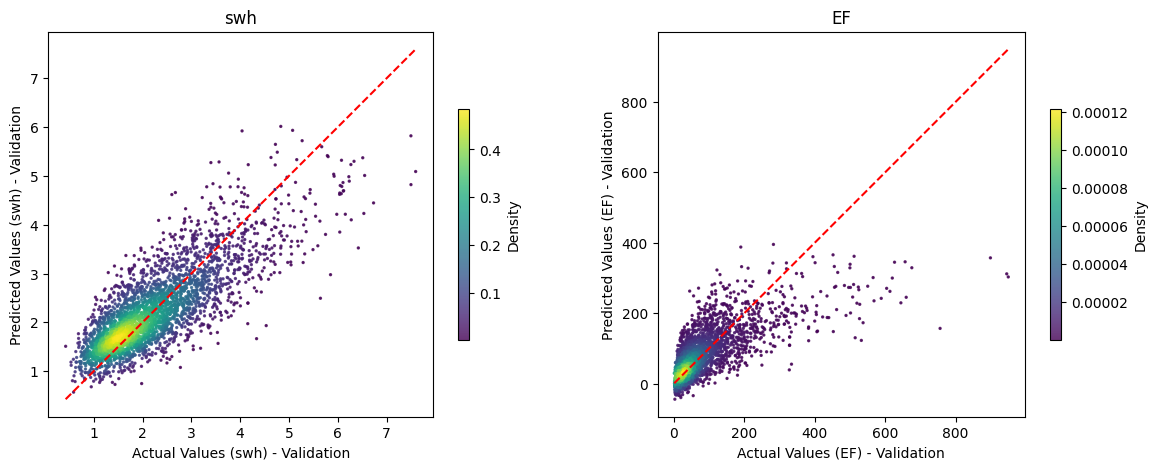

In [28]:
n_pcs = pca.pca.n_components_  # This is the number of PCs to use as X

common_times = np.intersect1d(pca.pcs.time, waves.time)

X = pca.pcs.sel(time=common_times).PCs.isel(n_component=range(n_pcs)).values
Ys = waves.sel(time=common_times).to_dataframe()[waves.data_vars.keys()].values

fit_plot_linear_model(X, Ys, keys=list(waves.data_vars.keys()), perc_train=0.8)

## DYNAMIC Predictor- Load large scale atmospheric variables
### Generate ESTELA

In [29]:
ob_est = ESTELA(p_waves="", save_monthly=True, only_sea=True)
ob_est.set_site(
    site="inputs", location=[-8.812405 + 360, 40.645615]
)  # define lon within [0-360]
ob_est.set_years(years=[1980, 2024])
ob_est.get_estela(
    do_estela=False
)  # If do_estela = False  it will only load the previously executed estela

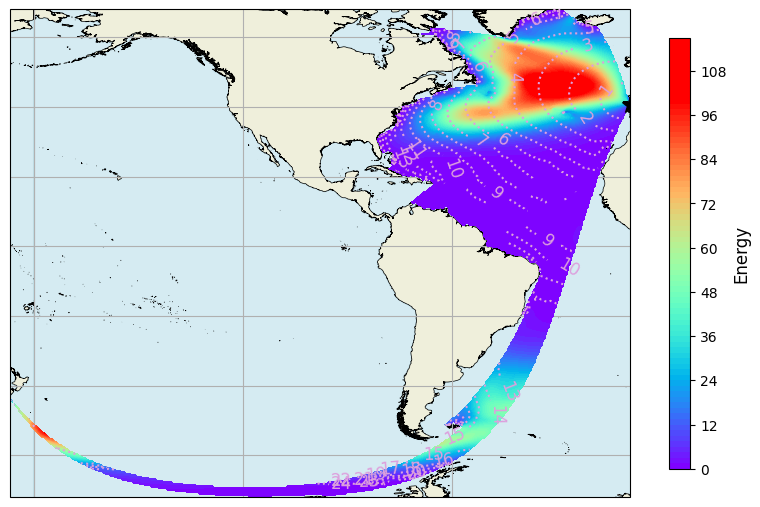

In [30]:
ob_est.plot_mean_estela(
    custom_params={"central_longitude": ob_est.lon0, "vmax": 100, "figsize": [10, 8]}
);

### load mean sea level pressure, spatial gradient of mean sea level pressure INCLUDING SPATIAL-TEMPORAL LAGS by ESTELA

In [31]:
# Define the variables and region
variables = ["msl", "msl_gradient"]
region = (200, -10, 360, 80)
estela = True

# Load the ERA5 predictors
era5_dynamic = load_atmospheric_predictor(
    variables=variables, region=region, estela=estela
)
era5_dynamic

<xarray.Dataset> Size: 124MB
Dimensions:       (time: 16802, latitude: 23, longitude: 40)
Coordinates:
  * latitude      (latitude) float32 92B 80.0 76.0 72.0 68.0 ... 0.0 -4.0 -8.0
  * longitude     (longitude) float32 160B 200.0 204.0 208.0 ... 352.0 356.0
  * time          (time) datetime64[s] 134kB 1979-01-01 ... 2024-12-31
Data variables:
    msl           (time, latitude, longitude) float32 62MB nan nan ... nan nan
    msl_gradient  (time, latitude, longitude) float32 62MB nan nan ... nan nan
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [2]:
# # If cell above takes too long, run:
# !wget https://geoocean.sci.unican.es/data/era5_predictor_dynamic_aveiro.nc -P inputs/

# # Then run:
# era5_dynamic = xr.open_dataset("inputs/era5_predictor_dynamic_aveiro.nc")
# era5_dynamic

## Predictor- define indices/covariates/input layers
### PCA- Principal Component Analysis + reduce dimensionality

In [32]:
pca_dynamic = PCA(n_components=0.95)

pca_dynamic.fit_transform(
    data=era5_dynamic,
    vars_to_stack=["msl", "msl_gradient"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
    value_to_replace_nans={"msl": 101325.0, "msl_gradient": 0.0},
)

2025-08-26 07:02:18,697 - PCA - WARNING - Using 205 out of 920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-26 07:02:18,814 - PCA - WARNING - Data contains NaNs.
2025-08-26 07:02:19,002 - PCA - WARNING - Using 205 out of 920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-26 07:02:19,140 - PCA - WARNING - Data contains NaNs.


<xarray.Dataset> Size: 12MB
Dimensions:      (time: 16802, n_component: 175)
Coordinates:
  * time         (time) datetime64[s] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * n_component  (n_component) int64 1kB 0 1 2 3 4 5 ... 169 170 171 172 173 174
Data variables:
    PCs          (time, n_component) float32 12MB -11.92 9.62 ... 0.2112
    stds         (n_component) float32 700B 7.049 6.486 5.026 ... 0.5675 0.5618

### PCA- spatial modes EOF

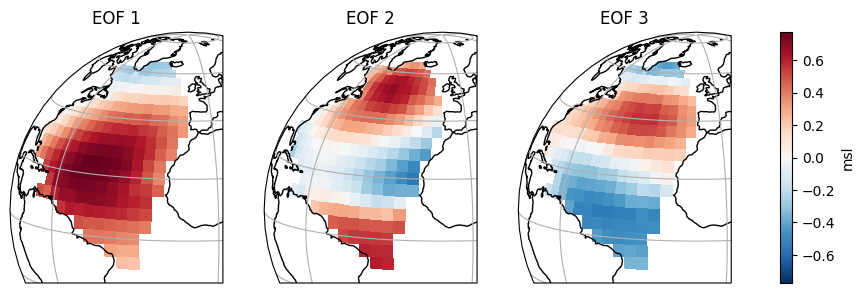

In [33]:
pca_dynamic.plot_eofs(
    num_eofs=3, vars_to_plot=["msl"], destandarize=True, map_center=(-10, 10)
)

### PCA- temporal indices PCs

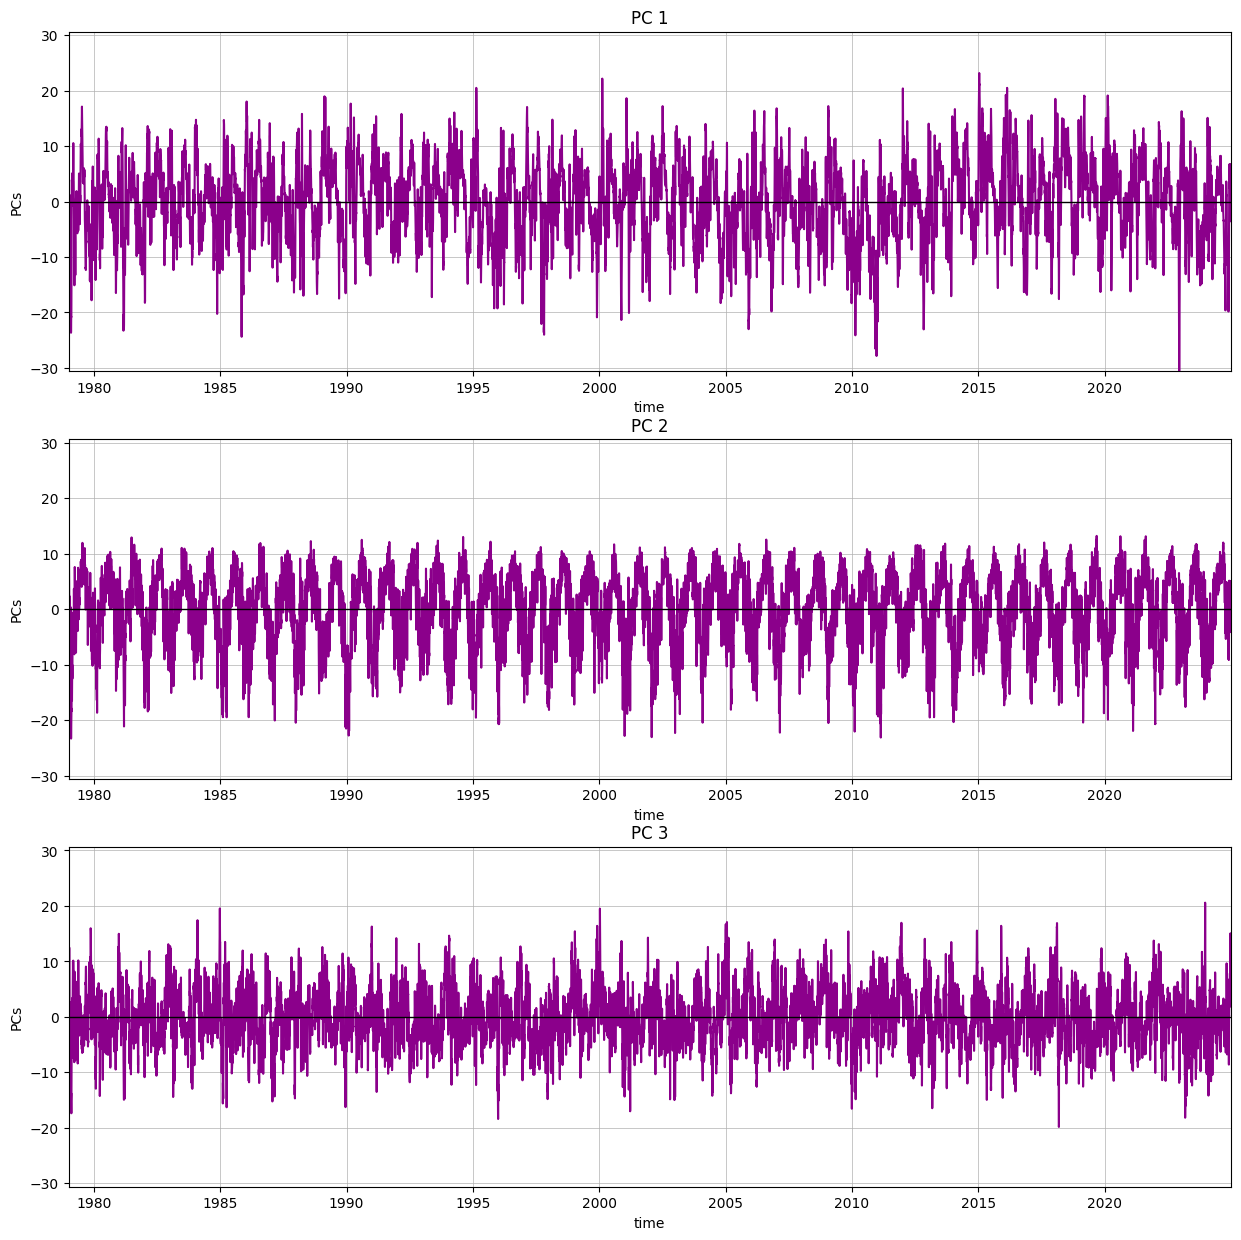

In [34]:
n_pcs = 3
plot_pcs(pca_dynamic, n_pcs)

## Predictand- Load regional/local wave data
### significant wave height, peak period

In [35]:
pca_dynamic.pcs

<xarray.Dataset> Size: 12MB
Dimensions:      (time: 16802, n_component: 175)
Coordinates:
  * time         (time) datetime64[s] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
  * n_component  (n_component) int64 1kB 0 1 2 3 4 5 ... 169 170 171 172 173 174
Data variables:
    PCs          (time, n_component) float32 12MB -11.92 9.62 ... 0.2112
    stds         (n_component) float32 700B 7.049 6.486 5.026 ... 0.5675 0.5618

## Predictand to Predictor - Model
### Multiple Linear Regression
X - temporal indices PCs- Predictor: regressors, exogenous variables, explanatory variables, covariates, input variables, predictor variables, or independent variables

Y - wave parameter- Predictand: regressand, endogenous variable, response variable, target variable, measured variable, criterion variable, or dependent variable

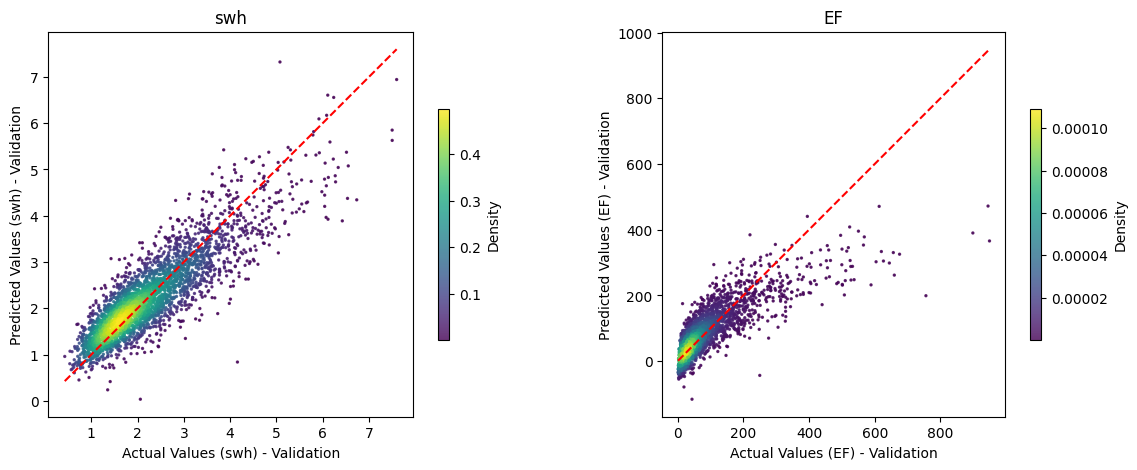

In [37]:
n_pcs = pca_dynamic.pca.n_components_

common_times = np.intersect1d(pca_dynamic.pcs.time, waves.time)

X = pca_dynamic.pcs.sel(time=common_times).PCs.isel(n_component=range(n_pcs)).values
Ys = waves.sel(time=common_times).to_dataframe()[waves.data_vars.keys()].values

fit_plot_linear_model(X, Ys, keys=list(waves.data_vars.keys()), perc_train=0.8)